In [2]:
import glob

import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
from scipy.stats import pearsonr

## Configuration

In [11]:
start = 1940
start_ERA5 = 1950
stop = 2023
stop_ERA5 = 2022

nens = 10
ts_or_td = "TD"

train_start = 1979
train_stop = 2019

years = np.arange(start, stop + 1)
years_ERA5 = np.arange(start_ERA5, stop_ERA5 + 1)

# Masks
mask_train = (years >= train_start) & (years <= train_stop)
mask_outside = ~mask_train
mask_outside_ERA5 = ((years >= start_ERA5) & (years < train_start)) | ((years > train_stop) & (years <= stop_ERA5))

alpha = 0.05

## File lists

In [4]:
# TC track files — one list per year, one per ensemble member
namelist_f = [
    [
        f"/glade/work/smhenry/NeuralGCM/data/tracks/factual/ens{ens}_{yr}_JASO_TC_tracks_factual.txt"
        for ens in range(1, nens + 1)
    ]
    for yr in range(start, stop + 1)
]

# Zonal wind files (ensmean)
path_hist = (
    "/glade/derecho/scratch/smhenry/neuralGCM/sims/factual-historical/ensmean_JASO/"
)
path_fact = "/glade/work/smhenry/neuralGCM/sims/factual/ensmean_JASO/"

hist_stop = 2003  # last year in factual-historical

namelist_u = [
    path_hist + f"{yr}_ensmean_JASO_factual-historical_raw.nc"
    if yr <= hist_stop
    else path_fact + f"{yr}_ensmean_JASO_factual_raw.nc"
    for yr in range(start, stop + 1)
]

## TC count functions

In [5]:
def count_NA(file):
    count, in_TC, is_in_NA = 0, False, False
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NA:
                    count += 1
                is_in_NA, in_TC = False, True
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon, lat = float(data[2]), float(data[3])
                    if (
                        (285 <= lon <= 360 and 0 <= lat <= 50)
                        or (276 <= lon < 285 and 10 <= lat <= 50)
                        or (262 <= lon < 276 and 16.5 <= lat <= 50)
                    ):
                        is_in_NA = True
    if is_in_NA:
        count += 1
    return count


def count_NWP(file):
    count, in_TC, is_in_NWP = 0, False, False
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NWP:
                    count += 1
                is_in_NWP, in_TC = False, True
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon, lat = float(data[2]), float(data[3])
                    if 100 <= lon <= 180 and 0 <= lat <= 50:
                        is_in_NWP = True
    if is_in_NWP:
        count += 1
    return count


def count_NEP(file):
    count, in_TC, is_in_NEP = 0, False, False
    with open(file, "r") as df:
        for line in df:
            if line.startswith("start"):
                if is_in_NEP:
                    count += 1
                is_in_NEP, in_TC = False, True
            elif in_TC:
                data = line.split()
                if len(data) >= 4:
                    lon, lat = float(data[2]), float(data[3])
                    if (
                        (275 <= lon <= 284 and 0 <= lat <= 10)
                        or (260 <= lon < 275 and 0 <= lat <= 16.5)
                        or (180 <= lon < 260 and 0 <= lat <= 50)
                    ):
                        is_in_NEP = True
    if is_in_NEP:
        count += 1
    return count


def count_TCs_ibtracs(year, basin, storm_type):
    df = pd.read_csv(
        f"/glade/work/smhenry/NeuralGCM/data/ibtracs/IBTrACS_{year}_JASO.csv"
    )
    df["time"] = pd.to_datetime(df["time"])
    durations = df.groupby("stormid")["time"].agg(
        lambda x: (x.max() - x.min()).total_seconds() / 3600
    )
    valid = durations[durations >= 54].index
    df = df[df["stormid"].isin(valid) & df["stormid"].str.contains(basin)]
    type_dict = {
        "TD": "HU|HR|TY|ST|TS|TC|SS|TD|SD",
        "TS": "HU|HR|TY|ST|TS|TC|SS",
        "HU": "HU|HR|TY|ST",
    }
    if storm_type in type_dict:
        df = df[df["type"].str.contains(type_dict[storm_type])]
    return df["stormid"].nunique()

## Build TC count arrays

In [6]:
f_exclude = [
    [1992, 3],
    [2005, 17],
    [2012, 14],
    [2017, 3],
    [2017, 12],
    [2017, 13],
    [2021, 16],
]

print("Counting factual TC tracks...")
f_counts = {
    basin: np.full((len(years), nens), np.nan) for basin in ["NA", "NWP", "NEP"]
}
count_fn = {"NA": count_NA, "NWP": count_NWP, "NEP": count_NEP}

for iyr in range(len(years)):
    for iens in range(nens):
        skip = any(iyr == (e[0] - start) and iens == (e[1] - 1) for e in f_exclude)
        if not skip:
            for basin in ["NA", "NWP", "NEP"]:
                f_counts[basin][iyr, iens] = count_fn[basin](namelist_f[iyr][iens])

# Ensemble mean per year
f_ensmean = {
    basin: xr.DataArray(
        np.nanmean(f_counts[basin], axis=1), coords={"year": years}, dims=["year"]
    )
    for basin in ["NA", "NWP", "NEP"]
}

print("Counting IBTrACS observations...")
obs_counts = {
    "NA": [count_TCs_ibtracs(yr, "AL", ts_or_td) for yr in years],
    "NWP": [count_TCs_ibtracs(yr, "WP", ts_or_td) for yr in years],
    "NEP": [
        count_TCs_ibtracs(yr, "EP", ts_or_td) if yr >= 1949 else np.nan for yr in years
    ],
}
obs = {
    basin: xr.DataArray(
        np.array(obs_counts[basin], dtype=float), coords={"year": years}, dims=["year"]
    )
    for basin in ["NA", "NWP", "NEP"]
}

Counting factual TC tracks...
Counting IBTrACS observations...


## ACC, RMSE, and bias computation for TC frequency

In [7]:
def compute_index_stats(f_arr, obs_arr, mask):
    """
    Compute ACC, two-tailed p-value, RMSE, and bias for a given year mask.
    ACC is computed on anomalies relative to the subset mean.
    RMSE and bias are computed on the raw (non-anomaly) values, so that bias
    reflects the actual mean offset between the model and the reference.
    f_arr, obs_arr: 1-D numpy arrays indexed over all years.
    mask: boolean array selecting years to evaluate.
    Returns: r (ACC), p (p-value), rmse, bias (model - reference).
    """
    f_sub = f_arr[mask].astype(float)
    obs_sub = obs_arr[mask].astype(float)

    # Remove NaNs
    valid = ~np.isnan(f_sub) & ~np.isnan(obs_sub)
    f_sub, obs_sub = f_sub[valid], obs_sub[valid]

    if len(f_sub) < 3:
        return np.nan, np.nan, np.nan, np.nan

    # Anomalies relative to the subset mean, for ACC only
    f_anom = f_sub - f_sub.mean()
    obs_anom = obs_sub - obs_sub.mean()
    r, p = stats.pearsonr(f_anom, obs_anom)

    rmse = np.sqrt(np.mean((f_sub - obs_sub) ** 2))
    bias = np.mean(f_sub - obs_sub)

    return r, p, rmse, bias


print(
    f"{'Basin':>5} | {'Period':>20} | {'ACC':>6} | {'p-value':>8} | {'RMSE':>7} | {'Bias':>7}"
)
print("-" * 68)

tc_acc_results = {}
for basin in ["NA", "NWP", "NEP"]:
    f_arr = f_ensmean[basin].values
    obs_arr = obs[basin].values
    tc_acc_results[basin] = {}
    for period_label, mask in [
        ("Training (1979–2019)", mask_train),
        ("(1940-1978)&(2020-2023)", mask_outside),
    ]:
        r, p, rmse, bias = compute_index_stats(f_arr, obs_arr, mask)
        tc_acc_results[basin][period_label] = {
            "ACC": r,
            "p": p,
            "RMSE": rmse,
            "Bias": bias,
        }
        print(
            f"{basin:>5} | {period_label:>20} | {r:>6.3f} | {p:>8.4f} | {rmse:>7.2f} | {bias:>7.2f}"
        )

Basin |               Period |    ACC |  p-value |    RMSE |    Bias
--------------------------------------------------------------------
   NA | Training (1979–2019) |  0.582 |   0.0001 |    6.08 |   -5.39
   NA | (1940-1978)&(2020-2023) |  0.333 |   0.0291 |    6.94 |   -5.70
  NWP | Training (1979–2019) |  0.305 |   0.0522 |   10.05 |   -9.03
  NWP | (1940-1978)&(2020-2023) | -0.404 |   0.0073 |    9.12 |   -5.13
  NEP | Training (1979–2019) |  0.286 |   0.0700 |    7.93 |   -6.82
  NEP | (1940-1978)&(2020-2023) |  0.399 |   0.0195 |    5.03 |   -3.21


## Load zonal wind data (200 hPa & 850 hPa)

In [26]:
ERA5_dir = "/glade/derecho/scratch/smhenry/neuralGCM/Data/ERA5"
ERA5_paths = [ERA5_dir+f"/ERA5_U_{year}_JASO.nc" for year in years_ERA5]
ERA5_data = xr.open_mfdataset(ERA5_paths, combine='nested', concat_dim="year").assign_coords(year=years_ERA5)

u850_ERA5 = ERA5_data.U.sel(level=850)
u200_ERA5 = ERA5_data.U.sel(level=200)


f_data = xr.open_mfdataset(namelist_u, combine='nested', concat_dim="year").assign_coords(year=years).sel(latitude=slice(0,30))

u850_f = f_data.u_component_of_wind.sel(level=850)
u200_f = f_data.u_component_of_wind.sel(level=200)

u850_ERA5 = u850_ERA5.interp(
    latitude=u850_f.latitude,
    longitude=u850_f.longitude,
    method="linear"
)

u200_ERA5 = u200_ERA5.interp(
    latitude=u200_f.latitude,
    longitude=u200_f.longitude,
    method="linear"
)

print(u850_ERA5)
print(u850_f)

<xarray.DataArray 'U' (year: 73, latitude: 21, longitude: 256)> Size: 2MB
dask.array<transpose, shape=(73, 21, 256), dtype=float32, chunksize=(1, 21, 256), chunktype=numpy.ndarray>
Coordinates:
  * year       (year) int64 584B 1950 1951 1952 1953 ... 2019 2020 2021 2022
  * latitude   (latitude) float64 168B 0.7004 2.101 3.502 ... 25.91 27.31 28.72
  * longitude  (longitude) float64 2kB 0.0 1.406 2.812 ... 355.8 357.2 358.6
    level      float64 8B 850.0
Attributes: (12/14)
    long_name:                     U component of wind
    short_name:                    u
    units:                         m s**-1
    original_format:               WMO GRIB 1 with ECMWF local table
    ecmwf_local_table:             128
    ecmwf_parameter:               131
    ...                            ...
    grid_specification:            0.25 degree x 0.25 degree from 90N to 90S ...
    rda_dataset:                   ds633.5
    rda_dataset_url:               https:/rda.ucar.edu/datasets/ds633.5/
  

In [27]:
from scipy import stats
import numpy as np

train_years = np.arange(train_start, train_stop + 1)
outside_years = np.concatenate([
    np.arange(start_ERA5, train_start),
    np.arange(train_stop + 1, stop_ERA5 + 1)
])

def compute_spatial_stats(f_da, obs_da):
    """
    Compute spatial ACC, p-value, RMSE, and bias.

    f_da and obs_da should already be time-averaged DataArrays with
    dimensions (latitude, longitude).
    """

    f = f_da.values.ravel().astype(float)
    obs = obs_da.values.ravel().astype(float)

    valid = np.isfinite(f) & np.isfinite(obs)
    f = f[valid]
    obs = obs[valid]

    # ACC on spatial anomalies
    f_anom = f - f.mean()
    obs_anom = obs - obs.mean()

    r, p = stats.pearsonr(f_anom, obs_anom)

    # RMSE/Bias on raw fields
    rmse = np.sqrt(np.mean((f - obs) ** 2))
    bias = np.mean(f - obs)

    return r, p, rmse, bias


# -------------------------------------------------------
# Time-mean fields
# -------------------------------------------------------

u850_f_train = (
    u850_f
    .sel(year=train_years)
    .mean("year")
    .transpose("latitude", "longitude")
)

u850_ERA5_train = (
    u850_ERA5
    .sel(year=train_years)
    .mean("year")
)

u850_f_out = (
    u850_f
    .sel(year=outside_years)
    .mean("year")
    .transpose("latitude", "longitude")
)

u850_ERA5_out = (
    u850_ERA5
    .sel(year=outside_years)
    .mean("year")
)

u200_f_train = (
    u200_f
    .sel(year=train_years)
    .mean("year")
    .transpose("latitude", "longitude")
)

u200_ERA5_train = (
    u200_ERA5
    .sel(year=train_years)
    .mean("year")
)

u200_f_out = (
    u200_f
    .sel(year=outside_years)
    .mean("year")
    .transpose("latitude", "longitude")
)

u200_ERA5_out = (
    u200_ERA5
    .sel(year=outside_years)
    .mean("year")
)

# -------------------------------------------------------
# Print table
# -------------------------------------------------------

print(
    f"{'Variable':<28} {'ACC':>7} {'p-value':>10} {'RMSE':>10} {'Bias':>10}"
)
print("-" * 70)

rows = [
    ("850 hPa (Training)", u850_f_train, u850_ERA5_train),
    ("850 hPa (Outside)", u850_f_out, u850_ERA5_out),
    ("200 hPa (Training)", u200_f_train, u200_ERA5_train),
    ("200 hPa (Outside)", u200_f_out, u200_ERA5_out),
]

for label, f_field, obs_field in rows:
    r, p, rmse, bias = compute_spatial_stats(f_field, obs_field)

    print(
        f"{label:<28}"
        f"{r:7.3f}"
        f"{p:10.4f}"
        f"{rmse:10.3f}"
        f"{bias:10.3f}"
    )

Variable                         ACC    p-value       RMSE       Bias
----------------------------------------------------------------------
850 hPa (Training)            0.990    0.0000     0.607    -0.079
850 hPa (Outside)             0.986    0.0000     0.709     0.001
200 hPa (Training)            0.994    0.0000     0.972    -0.166
200 hPa (Outside)             0.984    0.0000     1.524     0.336


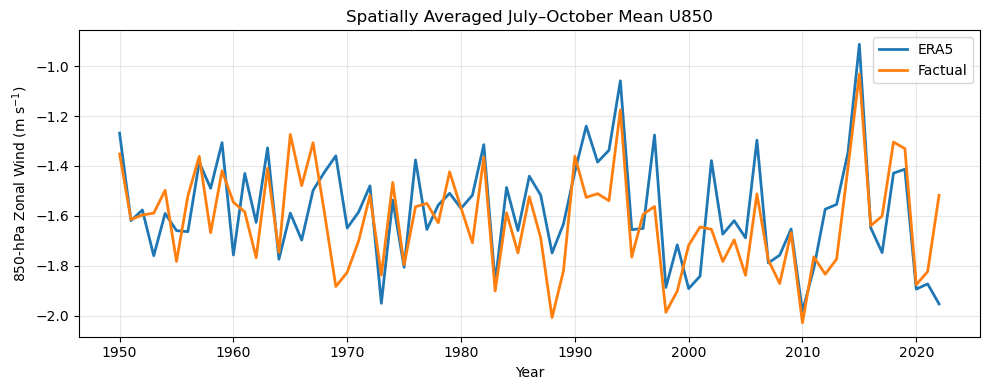

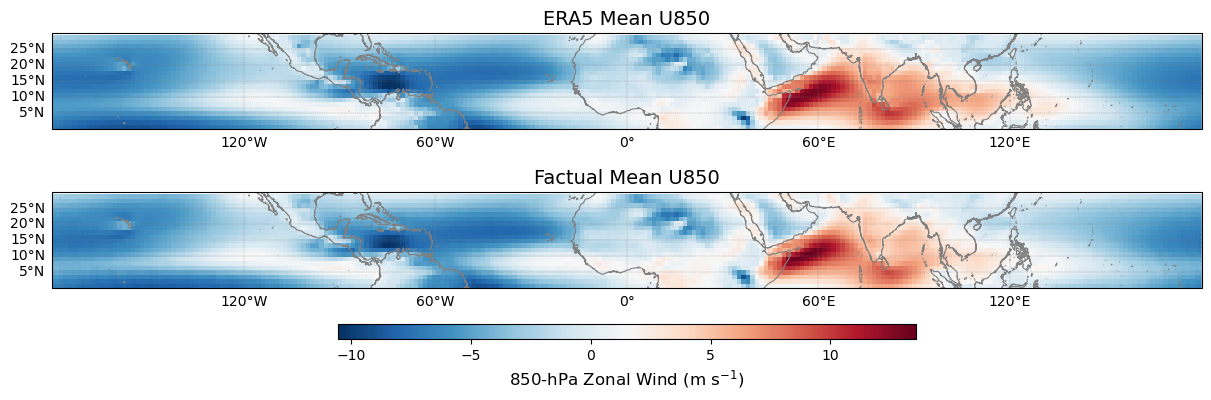

In [36]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------------------------------------------------
# Select common years
# --------------------------------------------------
common_years = np.intersect1d(u850_ERA5.year.values, u850_f.year.values)

era5 = u850_ERA5.sel(year=common_years)
factual = u850_f.sel(year=common_years)

# --------------------------------------------------
# Spatial averages (time series)
# --------------------------------------------------
era5_ts = era5.mean(dim=("latitude", "longitude"))
factual_ts = factual.mean(dim=("latitude", "longitude"))

fig, ax = plt.subplots(figsize=(10,4))

ax.plot(common_years, era5_ts, lw=2, label="ERA5")
ax.plot(common_years, factual_ts, lw=2, label="Factual")

ax.set_xlabel("Year")
ax.set_ylabel("850-hPa Zonal Wind (m s$^{-1}$)")
ax.set_title("Spatially Averaged July–October Mean U850")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Temporal means (maps)
# --------------------------------------------------
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

era5_map = era5.mean(dim="year")
factual_map = factual.mean(dim="year").transpose("latitude", "longitude")

vmin = min(float(era5_map.min()), float(factual_map.min()))
vmax = max(float(era5_map.max()), float(factual_map.max()))

fig, axs = plt.subplots(
    2,
    1,
    figsize=(12, 4),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

datasets = [
    (era5_map, "ERA5 Mean U850"),
    (factual_map, "Factual Mean U850"),
]

for ax, (data, title) in zip(axs, datasets):

    # Map formatting (matches reference)
    ax.set_extent([100, 350, 0, 30], crs=ccrs.PlateCarree())
    ax.coastlines(resolution="10m", linewidth=0.8, color="gray")

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        color="gray",
        alpha=0.7,
        linestyle="--",
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    pcm = ax.pcolormesh(
        data.longitude,
        data.latitude,
        data,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(title, fontsize=14)

# Shared horizontal colorbar
cbar = fig.colorbar(
    pcm,
    ax=axs,
    orientation="horizontal",
    pad=0.05,
    fraction=0.05,
    aspect=40,
)

cbar.set_label("850-hPa Zonal Wind (m s$^{-1}$)", fontsize=12)

plt.show()

-10.550297 13.142826
-10.495745 13.567795


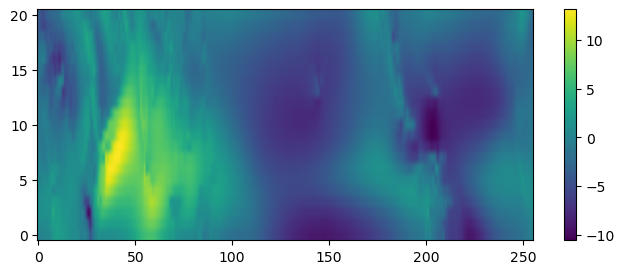

In [33]:
print(era5_map.min().values, era5_map.max().values)
print(factual_map.min().values, factual_map.max().values)

plt.figure(figsize=(8,3))
plt.imshow(era5_map, origin="lower", aspect="auto")
plt.colorbar()
plt.show()

In [8]:
# ── Factual and ERA5 zonal wind loaders, generalised over pressure level ────
# d633005: e5p.moda.an.pl  — back-extension monthly mean  1950–1978  (.nc)
# d633001: e5.moda.an.pl   — standard ERA5 monthly mean   1979–present (.nc)
# 1940–1949: no monthly-mean files on Glade → filled with NaN.
# Pre-1979 data carry the ECMWF lower-confidence flag.

JASO_IDX = [6, 7, 8, 9]  # 0-based Jul–Oct in a 12-month file


def _era5_nc_path(year):
    if year >= 1979:
        return (f"/gdex/data/d633001/e5.moda.an.pl/{year}/"
                f"e5.moda.an.pl.128_131_u.ll025uv.{year}010100_{year}120100.nc")
    elif year >= 1950:
        return (f"/gdex/data/d633005/e5p.moda.an.pl/{year}/"
                f"e5p.moda.an.pl.128_131_u.ll025uv.{year}010100_{year}120100.nc")
    else:
        return None  # 1940–1949: no monthly-mean files on Glade


def load_factual_u(level):
    """Load factual ensemble-mean zonal wind at a given pressure level."""
    ds_u_f = xr.open_mfdataset(
        namelist_u, combine="nested", concat_dim="year"
    ).assign_coords(year=years)
    return ds_u_f["u_component_of_wind"].sel(level=level, latitude=slice(-10, 50))


def load_era5_u(level, target_grid):
    """
    Load ERA5 monthly-mean zonal wind at a given pressure level, lazily
    (one year at a time), aligned onto `target_grid` (the factual DataArray
    for the same level).
    """
    yearly_era5 = []
    missing_years = []
    first_valid_da = None

    for yr in years:
        path = _era5_nc_path(yr)
        if path is None or not glob.glob(path):
            missing_years.append(int(yr))
            yearly_era5.append(None)
            continue

        ds = xr.open_dataset(path, chunks={"time": 4, "latitude": -1, "longitude": -1})
        u_var = next(
            (v for v in ds.data_vars
             if ds[v].attrs.get("GRIB_shortName", "") == "u"
             or ds[v].attrs.get("long_name", "").lower().startswith("u component")
             or v == "u"),
            list(ds.data_vars)[0],
        )
        da = (
            ds[u_var]
            .sel(latitude=slice(50, -10), level=level)
            .isel(time=JASO_IDX)
            .mean(dim="time")
            .drop_vars(["level", "valid_time", "step"], errors="ignore")
            .expand_dims(dim={"year": [int(yr)]})  # dim + index coord in one step
        )
        if first_valid_da is None:
            first_valid_da = da
        yearly_era5.append(da)

    # Fill missing years with NaN slices on the same spatial grid
    for i, (da, yr) in enumerate(zip(yearly_era5, years)):
        if da is None:
            yearly_era5[i] = xr.full_like(first_valid_da, fill_value=np.nan).assign_coords(year=[int(yr)])

    if missing_years:
        print(f"  ⚠ No ERA5 data for years {missing_years} at {level} hPa — filled with NaN.")

    u_era5 = (
        xr.concat(yearly_era5, dim="year")
        .chunk({"year": 84, "latitude": -1, "longitude": -1})
    )

    # Align onto the factual grid
    u_era5 = u_era5.reindex_like(target_grid, method="nearest", tolerance=0.01)

    assert u_era5.sizes == target_grid.sizes, (
        f"Grid mismatch at {level} hPa — ERA5 {dict(u_era5.sizes)} vs factual {dict(target_grid.sizes)}"
    )
    return u_era5


print("Loading factual zonal wind (850 hPa & 200 hPa)...")
u850_f = load_factual_u(850)
u200_f = load_factual_u(200)

print("Opening ERA5 monthly-mean NetCDF files (lazy, one year at a time)...")
u850_era5 = load_era5_u(850, u850_f)
u200_era5 = load_era5_u(200, u200_f)

print(f"u850_f : {dict(u850_f.sizes)}   u850_era5 : {dict(u850_era5.sizes)}  (lazy)")
print(f"u200_f : {dict(u200_f.sizes)}   u200_era5 : {dict(u200_era5.sizes)}  (lazy)")
print("ERA5 ready. Data loads on first .compute() call.")

def area_mean_0_30N(da):
    """
    Latitude-weighted (cos-lat) mean over 0-30N, simple mean over all
    longitudes. Handles either ascending or descending latitude ordering.
    Returns a 1-D DataArray indexed by year.
    """
    if da.latitude[0] > da.latitude[-1]:
        sub = da.sel(latitude=slice(30, 0))
    else:
        sub = da.sel(latitude=slice(0, 30))
    weights = np.cos(np.deg2rad(sub.latitude))
    weights = weights / weights.sum()
    return sub.weighted(weights).mean(dim=("latitude", "longitude"))


print("Computing 0–30°N regional-mean indices (this triggers the ERA5 loads)...")
u850_f_idx    = area_mean_0_30N(u850_f).compute()
u850_era5_idx = area_mean_0_30N(u850_era5).compute()
u200_f_idx    = area_mean_0_30N(u200_f).compute()
u200_era5_idx = area_mean_0_30N(u200_era5).compute()
print("Done.")

print(f"{'Period':>20} | {'ACC':>6} | {'p-value':>8} | {'RMSE (m/s)':>10} | {'Bias (m/s)':>10}")
print("-" * 66)

u200_results = {}
for period_label, mask in [("Training (1979–2019)", mask_train),
                            ("(1950-1978)&(2020-2023)",    mask_outside)]:
    r, p, rmse, bias = compute_index_stats(u200_f_idx.values, u200_era5_idx.values, mask)
    u200_results[period_label] = {"ACC": r, "p": p, "RMSE": rmse, "Bias": bias}
    print(f"{period_label:>20} | {r:>6.3f} | {p:>8.4f} | {rmse:>10.2f} | {bias:>10.2f}")
	
print(f"{'Period':>20} | {'ACC':>6} | {'p-value':>8} | {'RMSE (m/s)':>10} | {'Bias (m/s)':>10}")
print("-" * 66)

u850_results = {}
for period_label, mask in [("Training (1979–2019)", mask_train),
                            ("Outside training",    mask_outside)]:
    r, p, rmse, bias = compute_index_stats(u850_f_idx.values, u850_era5_idx.values, mask)
    u850_results[period_label] = {"ACC": r, "p": p, "RMSE": rmse, "Bias": bias}
    print(f"{period_label:>20} | {r:>6.3f} | {p:>8.4f} | {rmse:>10.2f} | {bias:>10.2f}")
	
rows = []
for period in ["Training (1979–2019)", "Outside training"]:
    r = u200_results[period]
    sig = "**" if r["p"] < 0.01 else ("*" if r["p"] < 0.05 else "")
    rows.append({
        "Period":     period,
        "ACC":        f"{r['ACC']:.3f}{sig}",
        "RMSE (m/s)": f"{r['RMSE']:.2f}",
        "Bias (m/s)": f"{r['Bias']:+.2f}",
    })

df_table2 = pd.DataFrame(rows).set_index("Period")
print("Table 2 — U200 (0–30°N): ACC, RMSE, Bias (* p<0.05, ** p<0.01)")
df_table2

Loading factual zonal wind (850 hPa & 200 hPa)...
Opening ERA5 monthly-mean NetCDF files (lazy, one year at a time)...


/glade/derecho/scratch/smhenry/tmp/ipykernel_40791/1034368516.py:46: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 4. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={"time": 4, "latitude": -1, "longitude": -1})
/glade/derecho/scratch/smhenry/tmp/ipykernel_40791/1034368516.py:46: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 4. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={"time": 4, "latitude": -1, "longitude": -1})
/glade/derecho/scratch/smhenry/tmp/ipykernel_40791/1034368516.py:46: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 4. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={"time": 4, "latitude": -1, "longitude": -1})
/gla

  ⚠ No ERA5 data for years [1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 2023] at 850 hPa — filled with NaN.


/glade/derecho/scratch/smhenry/tmp/ipykernel_40791/1034368516.py:46: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 4. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={"time": 4, "latitude": -1, "longitude": -1})
/glade/derecho/scratch/smhenry/tmp/ipykernel_40791/1034368516.py:46: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 4. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={"time": 4, "latitude": -1, "longitude": -1})
/glade/derecho/scratch/smhenry/tmp/ipykernel_40791/1034368516.py:46: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 4. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(path, chunks={"time": 4, "latitude": -1, "longitude": -1})
/gla

  ⚠ No ERA5 data for years [1940, 1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 2023] at 200 hPa — filled with NaN.
u850_f : {'year': 84, 'longitude': 256, 'latitude': 43}   u850_era5 : {'year': 84, 'latitude': 43, 'longitude': 256}  (lazy)
u200_f : {'year': 84, 'longitude': 256, 'latitude': 43}   u200_era5 : {'year': 84, 'latitude': 43, 'longitude': 256}  (lazy)
ERA5 ready. Data loads on first .compute() call.
Computing 0–30°N regional-mean indices (this triggers the ERA5 loads)...
Done.
              Period |    ACC |  p-value | RMSE (m/s) | Bias (m/s)
------------------------------------------------------------------
Training (1979–2019) |  0.798 |   0.0000 |       2.93 |       2.88
(1950-1978)&(2020-2023) |  0.698 |   0.0000 |       3.23 |       3.12
              Period |    ACC |  p-value | RMSE (m/s) | Bias (m/s)
------------------------------------------------------------------
Training (1979–2019) |  0.820 |   0.0000 |       0.38 |      -0.35
    Outside training |  0.

KeyError: 'Outside training'